## PREGUNTA DE NEGOCIO SEMANA 4

- Necessitem ajustar la nostra estratègia de negoci per alinear-nos amb les tendències nacionals i maximitzar les oportunitats de mercat. 
- És necessari ajustar les nostres ofertes al perfil del viatger ia la demanda de pernoctacions a les ciutats on estem presents, considerant les xifres oficials sobre procedència, mesos de visita i mitjana de pernoctacions per ctat autònoma?

--- Tendencias a estudiar:

- Estacionalización

- ¿Desestacionalización?


https://www.airdna.co/es-es/blog/short-term-rental-trends

https://repositorio.comillas.edu/jspui/bitstream/11531/79082/2/TFG%20-%20Lantero%20Hernandez%2C%20Isabel.pdf

https://lab.montera34.com/airbnb/donostia/estacionalidad/

https://www.airdna.co/es-es/blog/whats-the-best-airbnb-minimum-stay-policy

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind
from scipy.stats import shapiro
from scipy.stats import pearsonr, spearmanr
import numpy as np
import statsmodels.formula.api as smf
import statsmodels.api as sm
import warnings
warnings.filterwarnings("ignore")



from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from statsmodels.tsa.seasonal import seasonal_decompose
from prophet import Prophet

In [3]:
df = pd.read_csv(r"C:\Users\Usuario\Desktop\E19\ProjecteData\Equip_19\Data\datos_INE_consolidados_17112025.csv")
df.head()

,año,mes,provincia,pais_residencia,pernoctaciones,total_viajeros,media_pernoctaciones,fecha
0,2015,Enero,Islas Baleares,Total,25933.0,3705.0,7.00,2015-01-01
1,2015,Febrero,Islas Baleares,Total,30280.0,4382.0,6.91,2015-02-01
2,2015,Marzo,Islas Baleares,Total,46156.0,6536.0,7.06,2015-03-01
3,2015,Abril,Islas Baleares,Total,226542.0,36181.0,6.26,2015-04-01
4,2015,Mayo,Islas Baleares,Total,888610.0,145473.0,6.11,2015-05-01


In [4]:
df['fecha'] = pd.to_datetime(df['fecha'], errors='coerce')

df['mes_num'] = df['fecha'].dt.month

In [5]:
df.dtypes

año                              int64
mes                             object
provincia                       object
pais_residencia                 object
pernoctaciones                 float64
total_viajeros                 float64
media_pernoctaciones           float64
fecha                   datetime64[ns]
mes_num                          int32
dtype: object

In [6]:
df

,año,mes,provincia,pais_residencia,pernoctaciones,total_viajeros,media_pernoctaciones,fecha,mes_num
0,2015,Enero,Islas Baleares,Total,25933.0,3705.0,7.00,2015-01-01,1
1,2015,Febrero,Islas Baleares,Total,30280.0,4382.0,6.91,2015-02-01,2
2,2015,Marzo,Islas Baleares,Total,46156.0,6536.0,7.06,2015-03-01,3
3,2015,Abril,Islas Baleares,Total,226542.0,36181.0,6.26,2015-04-01,4
4,2015,Mayo,Islas Baleares,Total,888610.0,145473.0,6.11,2015-05-01,5
...,...,...,...,...,...,...,...,...,...
17047,2021,Agosto,Valencia,Resto del mundo,1408.0,361.0,3.90,2021-08-01,8
17048,2021,Septiembre,Valencia,Resto del mundo,1257.0,317.0,3.97,2021-09-01,9
17049,2021,Octubre,Valencia,Resto del mundo,1087.0,324.0,3.35,2021-10-01,10
17050,2021,Noviembre,Valencia,Resto del mundo,1279.0,361.0,3.54,2021-11-01,11


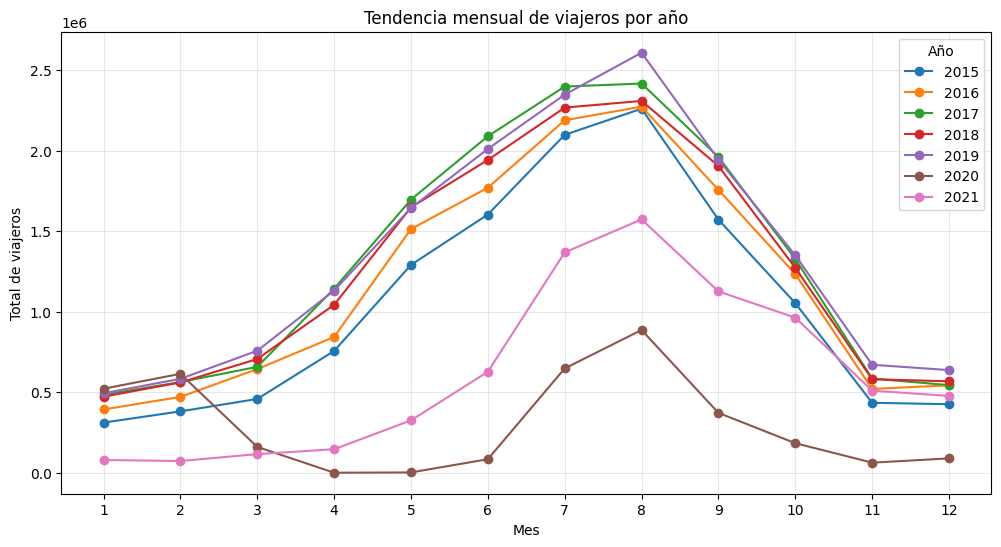

In [7]:
df_plot = df.groupby(['año', 'mes_num'])['total_viajeros'].sum().reset_index()

plt.figure(figsize=(12, 6))

for year in sorted(df_plot['año'].unique()):
    df_year = df_plot[df_plot['año'] == year]
    plt.plot(df_year['mes_num'], df_year['total_viajeros'], marker='o', label=str(year))

plt.title('Tendencia mensual de viajeros por año')
plt.xlabel('Mes')
plt.ylabel('Total de viajeros')
plt.xticks(range(1, 13))
plt.legend(title='Año')
plt.grid(alpha=0.3)

plt.show()



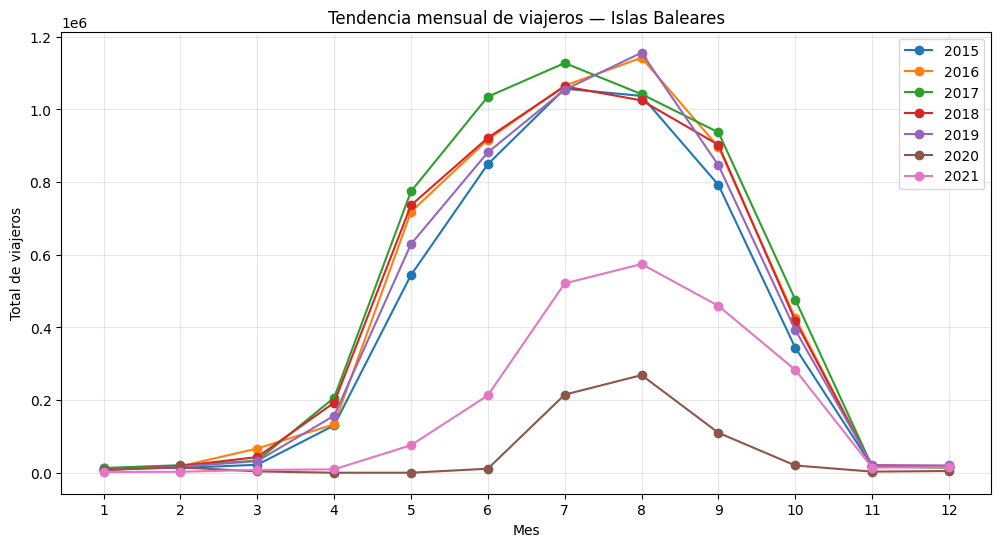

In [8]:
# Agrupar viajeros por año, provincia y mes
df_prov = df.groupby(['provincia', 'año', 'mes_num'])['total_viajeros'].sum().reset_index()

prov = "Islas Baleares"   # cambia a la provincia que quieras

df_p = df_prov[df_prov['provincia'] == prov]

plt.figure(figsize=(12,6))

for year in sorted(df_p['año'].unique()):
    df_y = df_p[df_p['año'] == year]
    plt.plot(df_y['mes_num'], df_y['total_viajeros'], marker='o', label=str(year))

plt.title(f"Tendencia mensual de viajeros — {prov}")
plt.xlabel("Mes")
plt.ylabel("Total de viajeros")
plt.xticks(range(1,13))
plt.grid(alpha=0.3)
plt.legend()
plt.show()



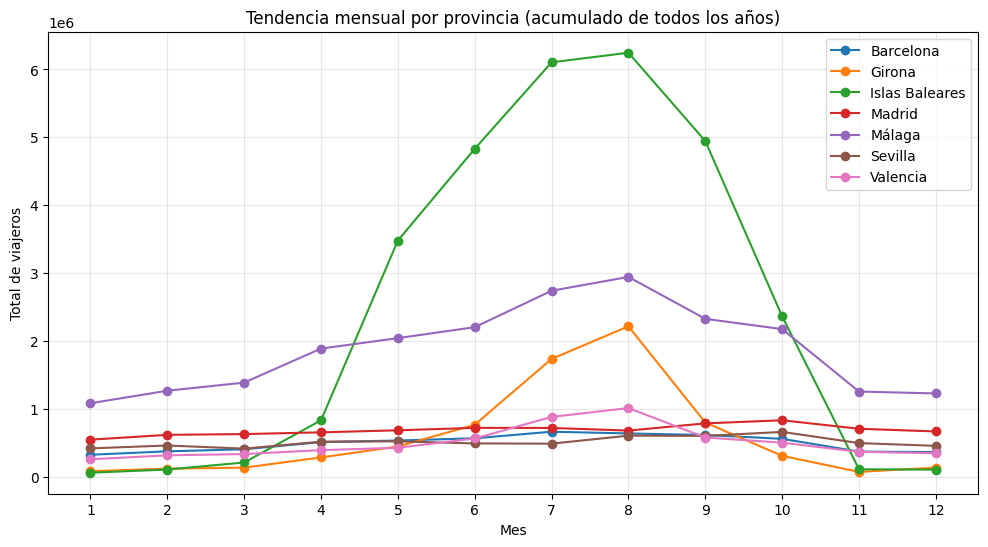

In [9]:
plt.figure(figsize=(12,6))

for prov in sorted(df['provincia'].unique()):
    df_p = df.groupby(['provincia','mes_num'])['total_viajeros'].sum().reset_index()
    df_sub = df_p[df_p['provincia'] == prov]
    plt.plot(df_sub['mes_num'], df_sub['total_viajeros'], marker='o', label=prov)

plt.title("Tendencia mensual por provincia (acumulado de todos los años)")
plt.xlabel("Mes")
plt.ylabel("Total de viajeros")
plt.xticks(range(1,13))
plt.grid(alpha=0.3)
plt.legend()
plt.show()


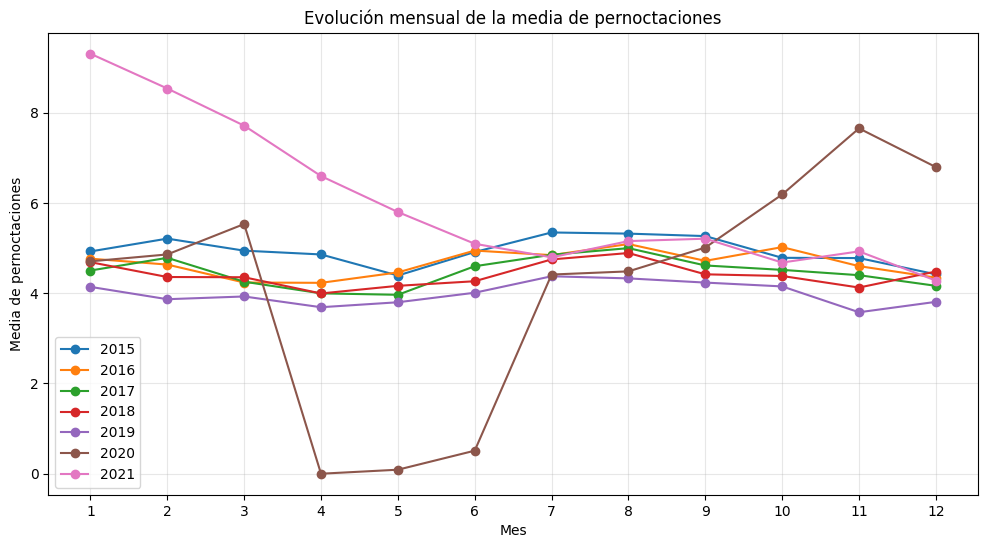

In [10]:
df_media = df.groupby(['año','mes_num'])['media_pernoctaciones'].mean().reset_index()

plt.figure(figsize=(12,6))

for year in df_media['año'].unique():
    df_y = df_media[df_media['año'] == year]
    plt.plot(df_y['mes_num'], df_y['media_pernoctaciones'], marker='o', label=str(year))

plt.title("Evolución mensual de la media de pernoctaciones")
plt.xlabel("Mes")
plt.ylabel("Media de pernoctaciones")
plt.xticks(range(1,13))
plt.grid(alpha=0.3)
plt.legend()
plt.show()


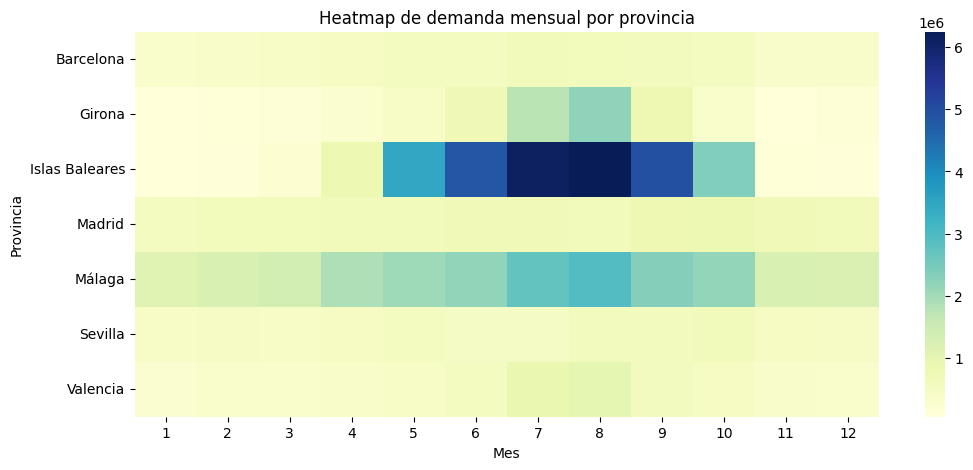

In [11]:
df_heat = df.groupby(['provincia', 'mes_num'])['total_viajeros'].sum().reset_index()
df_pivot = df_heat.pivot(index='provincia', columns='mes_num', values='total_viajeros')

plt.figure(figsize=(12,5))
sns.heatmap(df_pivot, cmap='YlGnBu')
plt.title("Heatmap de demanda mensual por provincia")
plt.xlabel("Mes")
plt.ylabel("Provincia")
plt.show()


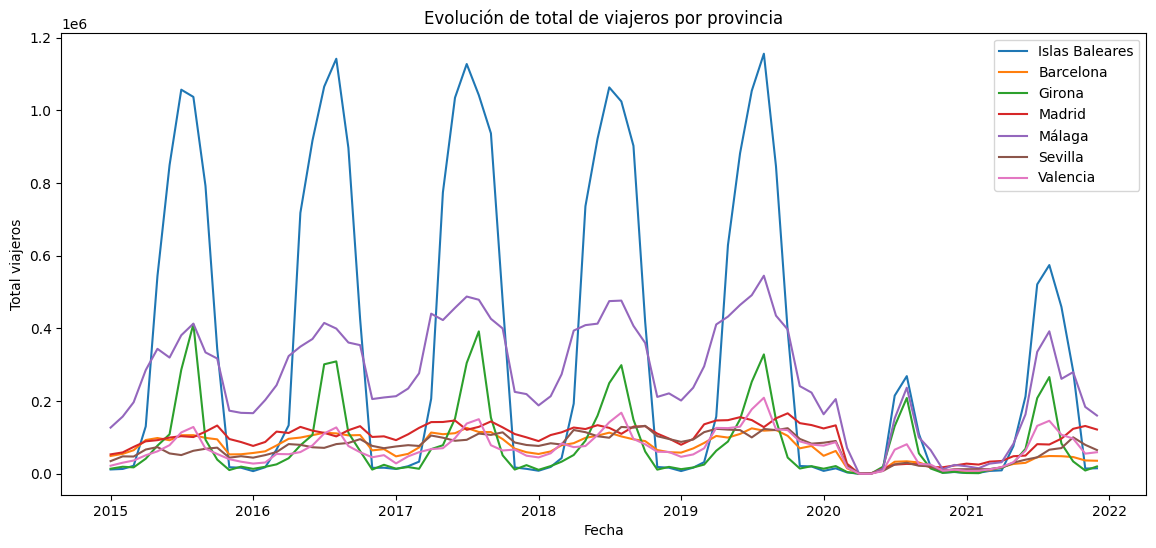

In [12]:
plt.figure(figsize=(14,6))

for provincia in df['provincia'].unique():
    # Agrupamos por fecha (datetime) y sumamos solo columnas numéricas
    df_prov = df[df['provincia'] == provincia].groupby('fecha')[['total_viajeros','pernoctaciones']].sum().reset_index()
    plt.plot(df_prov['fecha'], df_prov['total_viajeros'], label=provincia)

plt.title('Evolución de total de viajeros por provincia')
plt.xlabel('Fecha')
plt.ylabel('Total viajeros')
plt.legend()
plt.show()


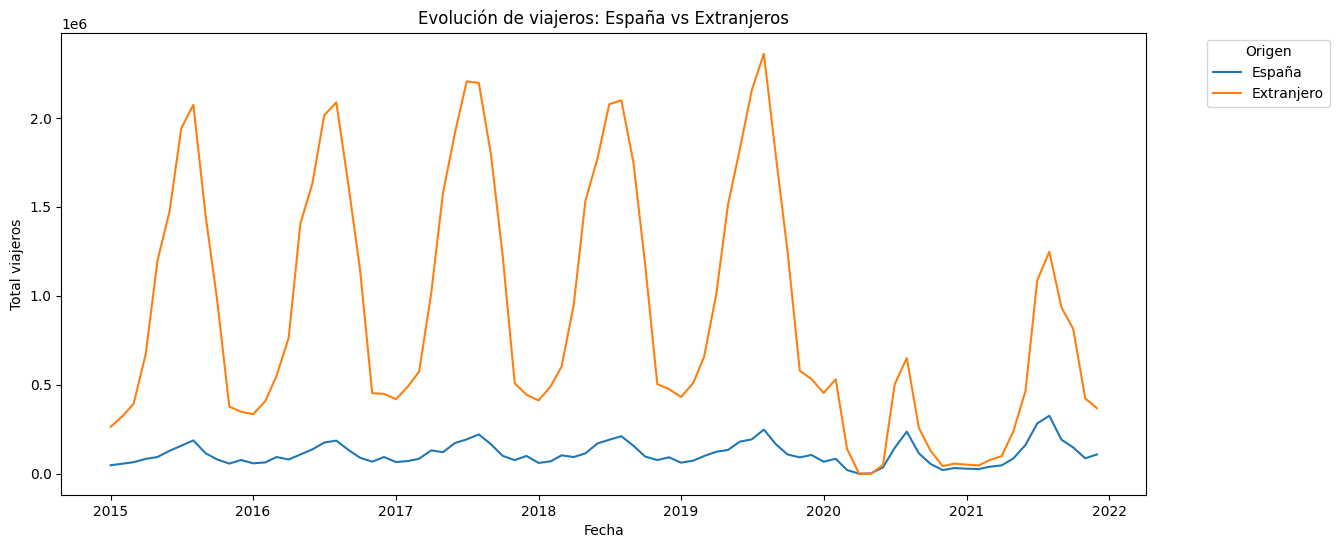

In [13]:
# Crear variable España vs Extranjeros
df['origen'] = df['pais_residencia'].apply(lambda x: 'España' if x == 'España' else 'Extranjero')

# Agrupar por fecha y origen
df_grouped_origen = df.groupby(['fecha','origen'])['total_viajeros'].sum().reset_index()

# Visualizar
plt.figure(figsize=(14,6))
sns.lineplot(data=df_grouped_origen, x='fecha', y='total_viajeros', hue='origen')
plt.title('Evolución de viajeros: España vs Extranjeros')
plt.xlabel('Fecha')
plt.ylabel('Total viajeros')
plt.legend(title="Origen", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()



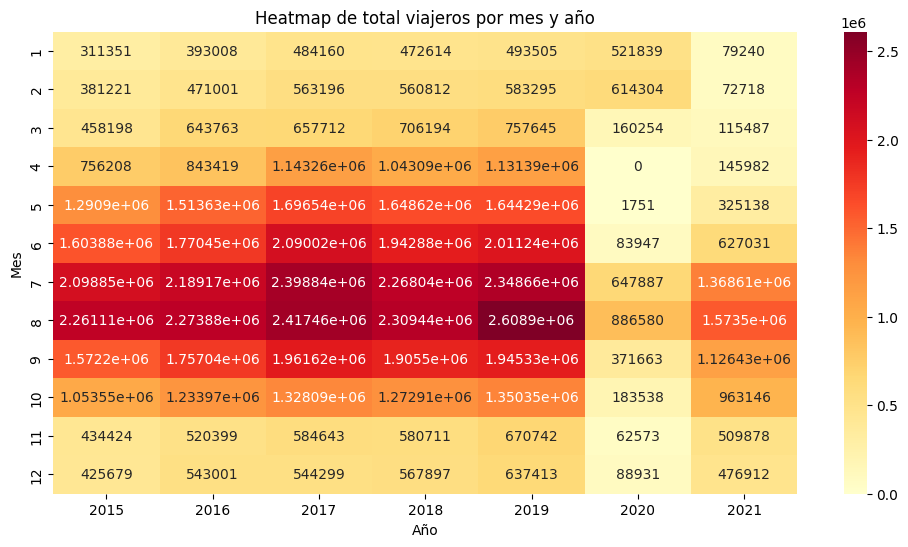

In [14]:
# Extraemos año y mes como enteros para pivot
df['año'] = df['fecha'].dt.year
df['mes'] = df['fecha'].dt.month

# Pivot: meses en filas, años en columnas
heatmap_data = df.groupby(['mes','año'])['total_viajeros'].sum().unstack()
plt.figure(figsize=(12,6))
sns.heatmap(heatmap_data, annot=True, fmt='g', cmap='YlOrRd')
plt.title('Heatmap de total viajeros por mes y año')
plt.xlabel('Año')
plt.ylabel('Mes')
plt.show()


## Estudio desestacionalización

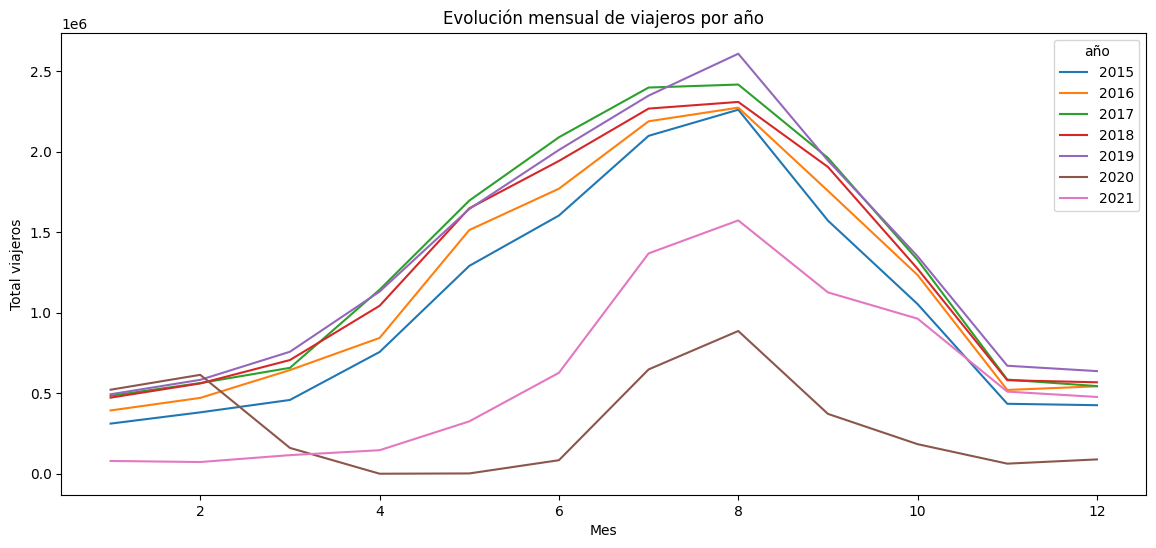

In [15]:
df['mes'] = df['fecha'].dt.month
df['año'] = df['fecha'].dt.year

# Media de viajeros por mes para cada año
df_grouped = df.groupby(['año','mes'])['total_viajeros'].sum().reset_index()

plt.figure(figsize=(14,6))
sns.lineplot(data=df_grouped, x='mes', y='total_viajeros', hue='año', palette='tab10')
plt.title('Evolución mensual de viajeros por año')
plt.xlabel('Mes')
plt.ylabel('Total viajeros')
plt.show()


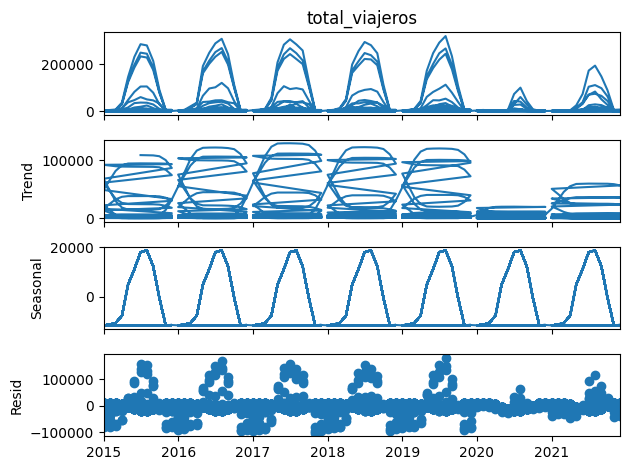

In [16]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Tomamos una provincia como ejemplo
provincia_ej = 'Islas Baleares'
ts = df[df['provincia']==provincia_ej].set_index('fecha')['total_viajeros']

# Descomposición aditiva
decomposition = seasonal_decompose(ts, model='additive', period=12)
decomposition.plot()
plt.show()


       fecha    periodo
0 2015-01-01  pre-COVID
1 2015-02-01  pre-COVID
2 2015-03-01  pre-COVID
3 2015-04-01  pre-COVID
4 2015-05-01  pre-COVID
5 2015-06-01  pre-COVID
6 2015-07-01  pre-COVID
7 2015-08-01  pre-COVID
8 2015-09-01  pre-COVID
9 2015-10-01  pre-COVID
periodo
pre-COVID     12586
post-COVID     4466
Name: count, dtype: int64


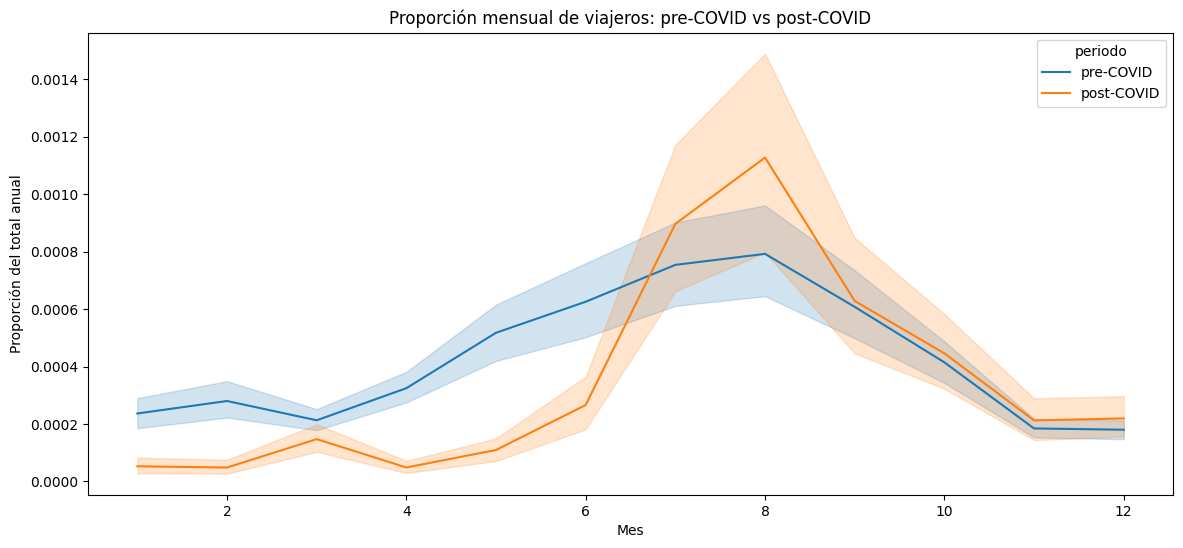

In [17]:
# Asegurarnos de que 'fecha' es datetime
df['fecha'] = pd.to_datetime(df['fecha'], errors='coerce')
df = df.dropna(subset=['fecha'])

# Crear columna 'periodo' pre/post COVID
df['periodo'] = df['fecha'].apply(lambda x: 'pre-COVID' if x < pd.Timestamp('2020-03-01') else 'post-COVID')

# Comprobamos
print(df[['fecha','periodo']].head(10))
print(df['periodo'].value_counts())


df['año'] = df['fecha'].dt.year
df['mes'] = df['fecha'].dt.month
df['total_anual'] = df.groupby('año')['total_viajeros'].transform('sum')
df['rel_mes'] = df['total_viajeros'] / df['total_anual']

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))
sns.lineplot(data=df, x='mes', y='rel_mes', hue='periodo')
plt.title('Proporción mensual de viajeros: pre-COVID vs post-COVID')
plt.xlabel('Mes')
plt.ylabel('Proporción del total anual')
plt.show()


Esto muestra cómo cambió la concentración de viajeros por mes debido a la pandemia.

Te permitirá distinguir la verdadera desestacionalización de un efecto temporal.

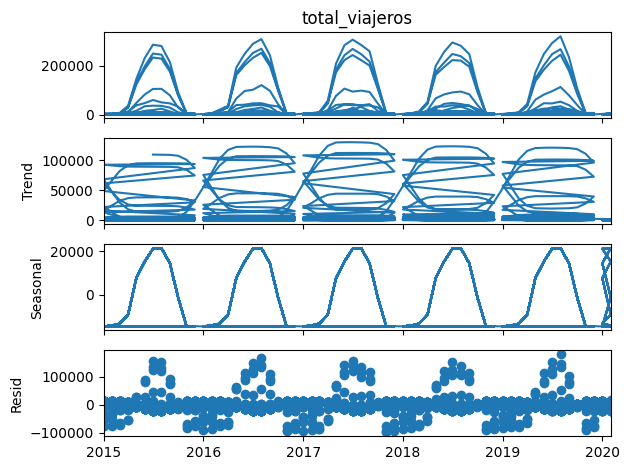

In [18]:
from statsmodels.tsa.seasonal import seasonal_decompose

provincia_ej = 'Islas Baleares'
ts_pre = df[(df['provincia']==provincia_ej) & (df['periodo']=='pre-COVID')].set_index('fecha')['total_viajeros']

decomposition = seasonal_decompose(ts_pre, model='additive', period=12)
decomposition.plot()
plt.show()


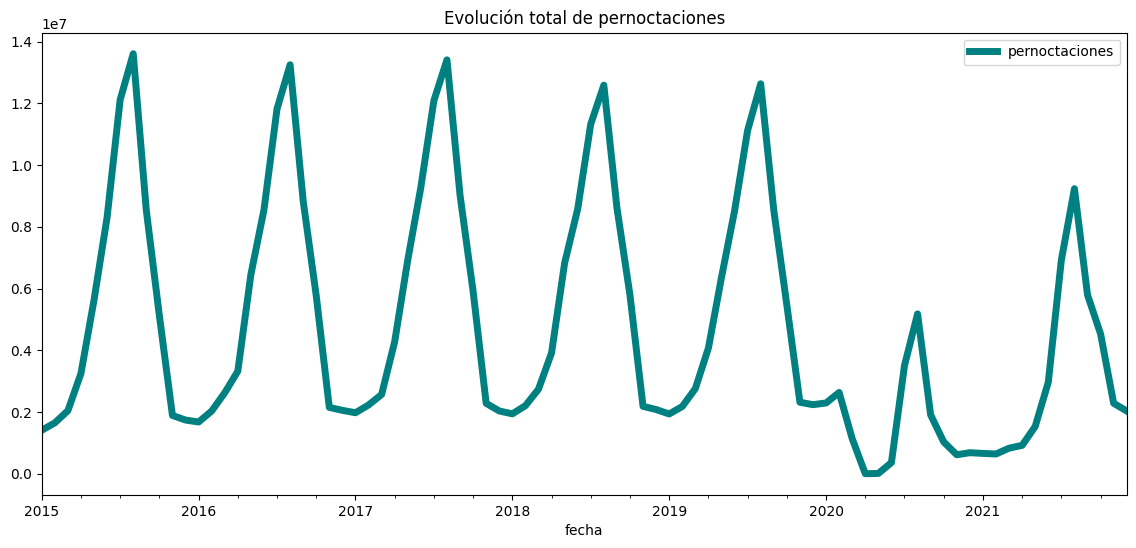

In [19]:
# Agrupar por fecha
pernoctaciones_por_año = df.groupby('fecha').agg({
    'total_viajeros': 'sum',
    'pernoctaciones': 'sum',
    'media_pernoctaciones': 'mean'
}).reset_index()

# Visualizar evolución de pernoctaciones
pernoctaciones_por_año.plot(
    x='fecha', 
    y='pernoctaciones', 
    kind='line', 
    figsize=(14,6), 
    title='Evolución total de pernoctaciones',
    color='teal',
    linewidth=5     
    )
plt.show()

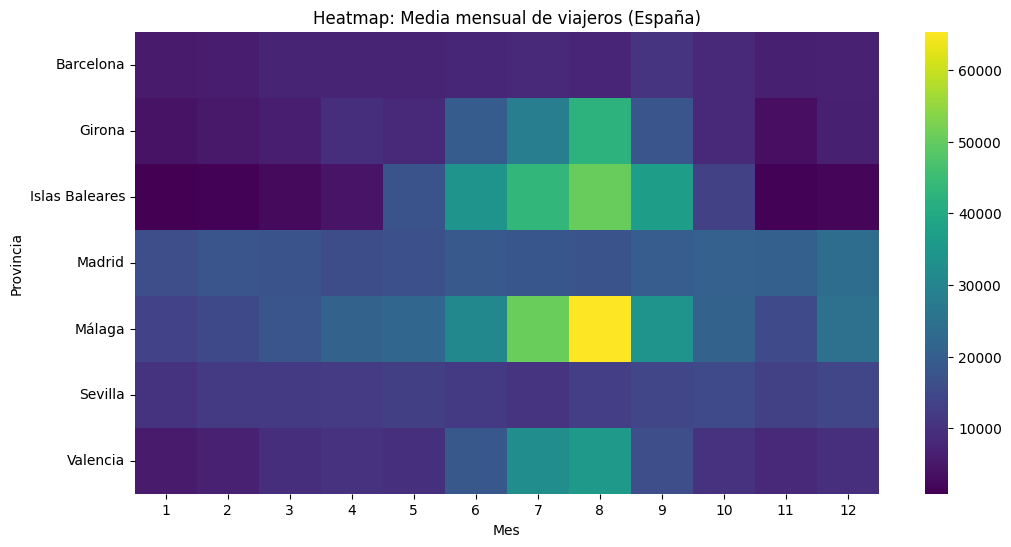

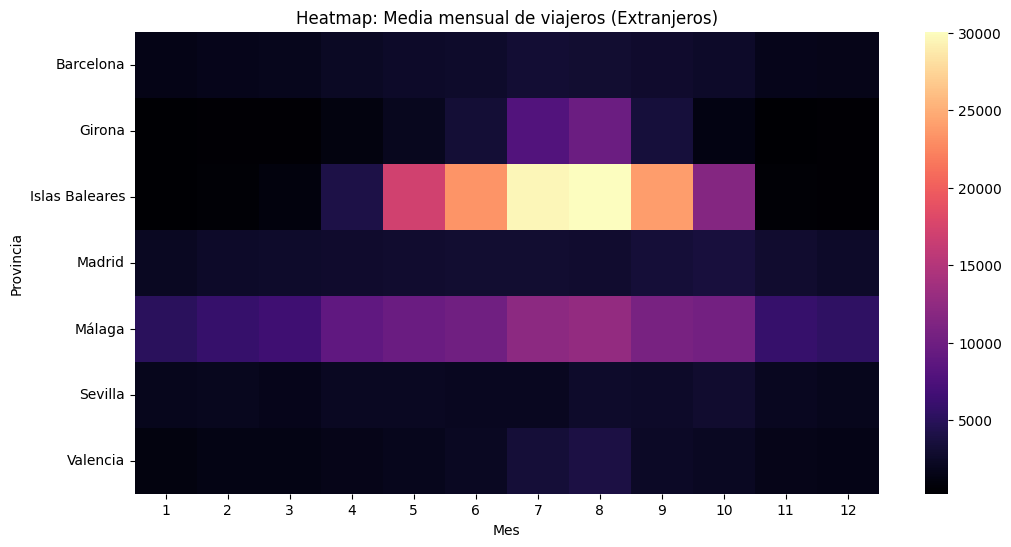

In [20]:
# Dividir dataset
df_esp = df[df['origen'] == 'España']
df_ext = df[df['origen'] == 'Extranjero']

# Pivot tables: media de viajeros por provincia y mes
pivot_esp = df_esp.pivot_table(
    index='provincia',
    columns='mes_num',
    values='total_viajeros',
    aggfunc='mean'
)

pivot_ext = df_ext.pivot_table(
    index='provincia',
    columns='mes_num',
    values='total_viajeros',
    aggfunc='mean'
)

plt.figure(figsize=(12,6))
sns.heatmap(pivot_esp, cmap='viridis')
plt.title('Heatmap: Media mensual de viajeros (España)')
plt.xlabel('Mes')
plt.ylabel('Provincia')
plt.show()


plt.figure(figsize=(12,6))
sns.heatmap(pivot_ext, cmap='magma')
plt.title('Heatmap: Media mensual de viajeros (Extranjeros)')
plt.xlabel('Mes')
plt.ylabel('Provincia')
plt.show()


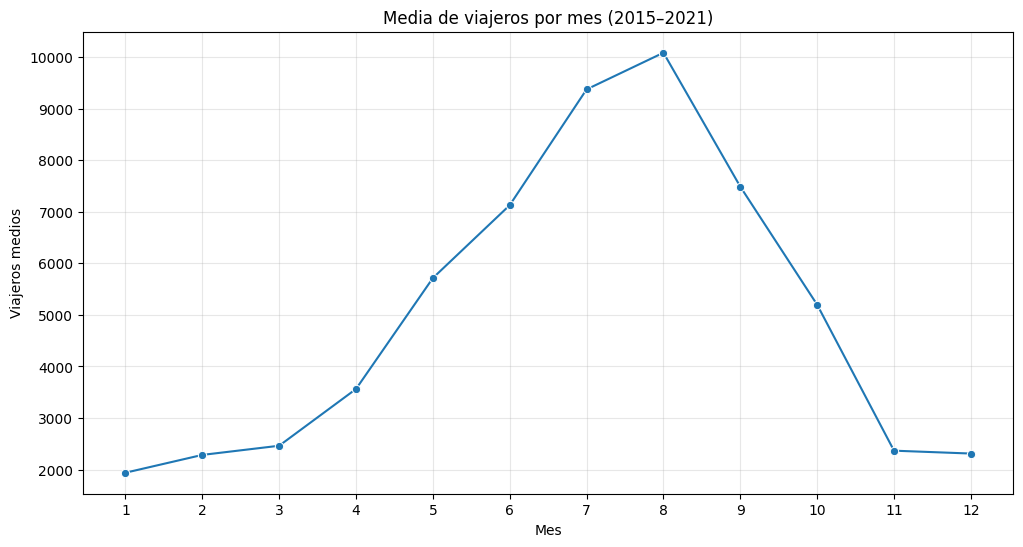

In [21]:
# Media de viajeros por mes
media_mes = df.groupby('mes_num')['total_viajeros'].mean().reset_index()

plt.figure(figsize=(12,6))
sns.lineplot(data=media_mes, x='mes_num', y='total_viajeros', marker='o')
plt.title('Media de viajeros por mes (2015–2021)')
plt.xlabel('Mes')
plt.ylabel('Viajeros medios')
plt.xticks(range(1,13))
plt.grid(True, alpha=0.3)
plt.show()


Identifica estacionalidad general.

Verás claramente los picos de verano.

Permite comparar años posteriores con patrón promedio.

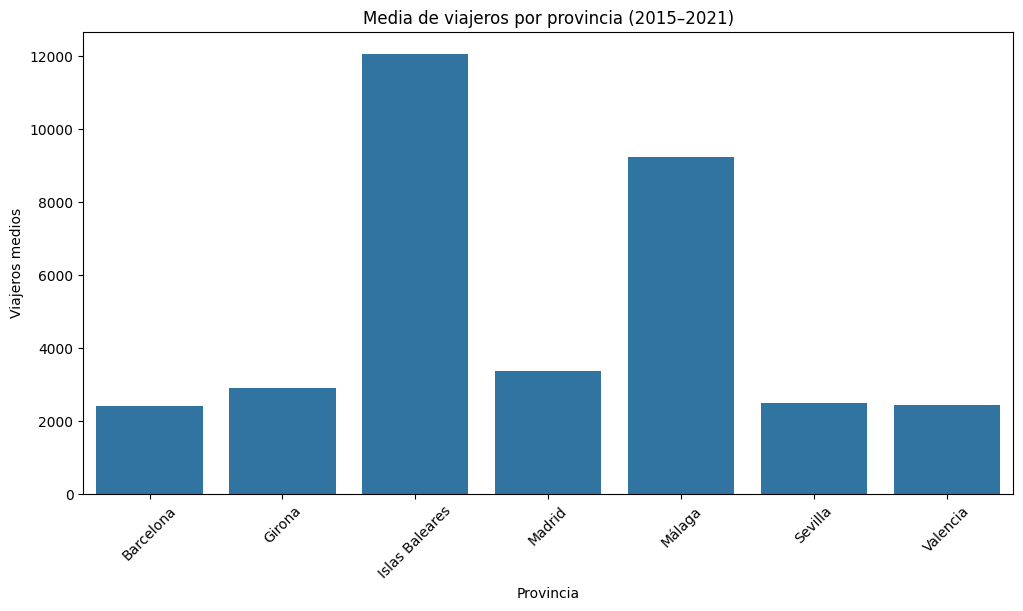

In [22]:
media_prov = df.groupby('provincia')['total_viajeros'].mean().reset_index()

plt.figure(figsize=(12,6))
sns.barplot(data=media_prov, x='provincia', y='total_viajeros')
plt.title('Media de viajeros por provincia (2015–2021)')
plt.xlabel('Provincia')
plt.ylabel('Viajeros medios')
plt.xticks(rotation=45)
plt.show()


Revela el peso turístico relativo de cada destino.

Permite priorizar dónde ajustar ofertas según demanda estructural.

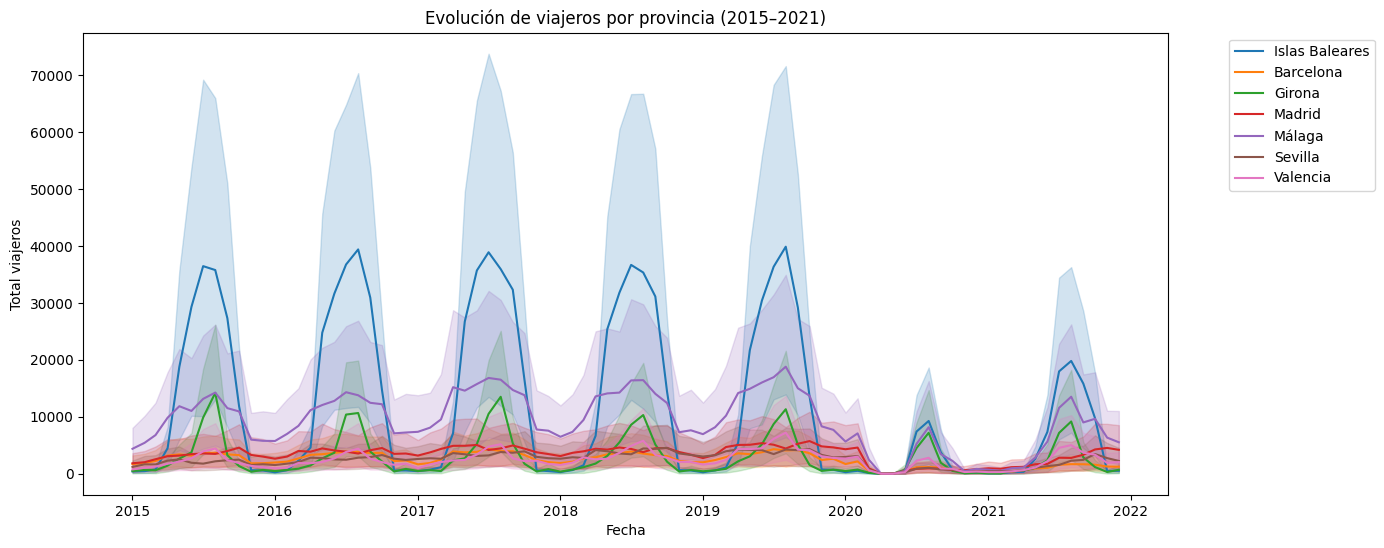

In [23]:
plt.figure(figsize=(14,6))
sns.lineplot(data=df, x='fecha', y='total_viajeros', hue='provincia')
plt.title('Evolución de viajeros por provincia (2015–2021)')
plt.xlabel('Fecha')
plt.ylabel('Total viajeros')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


Muestra claramente qué provincias tienen curvas más altas
Permite analizar impacto COVID
Detecta estacionalidad provincia a provincia

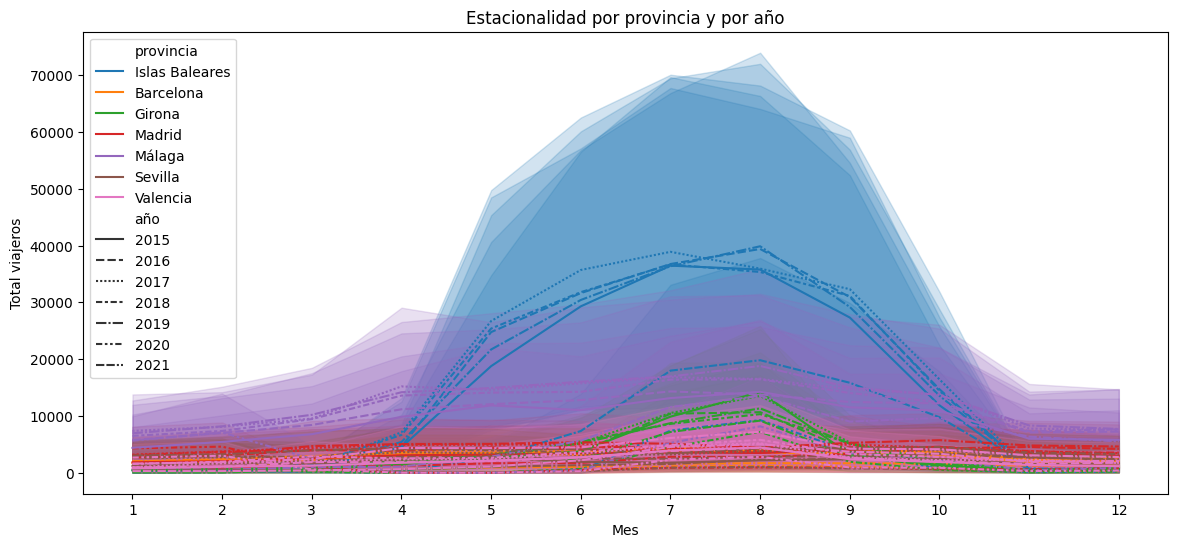

In [24]:
plt.figure(figsize=(14,6))
sns.lineplot(
    data=df,
    x='mes',
    y='total_viajeros',
    hue='provincia',
    style='año',   # cada año en estilo distinto
    markers=False
)
plt.title('Estacionalidad por provincia y por año')
plt.xlabel('Mes')
plt.ylabel('Total viajeros')
plt.xticks(range(1,13))
plt.show()


✔️ Cada provincia tiene una línea “por año”, útil para comparar
✔️ Puedes ver si la estacionalidad sube o baja
✔️ Permite detectar cambios post-COVID en la curva

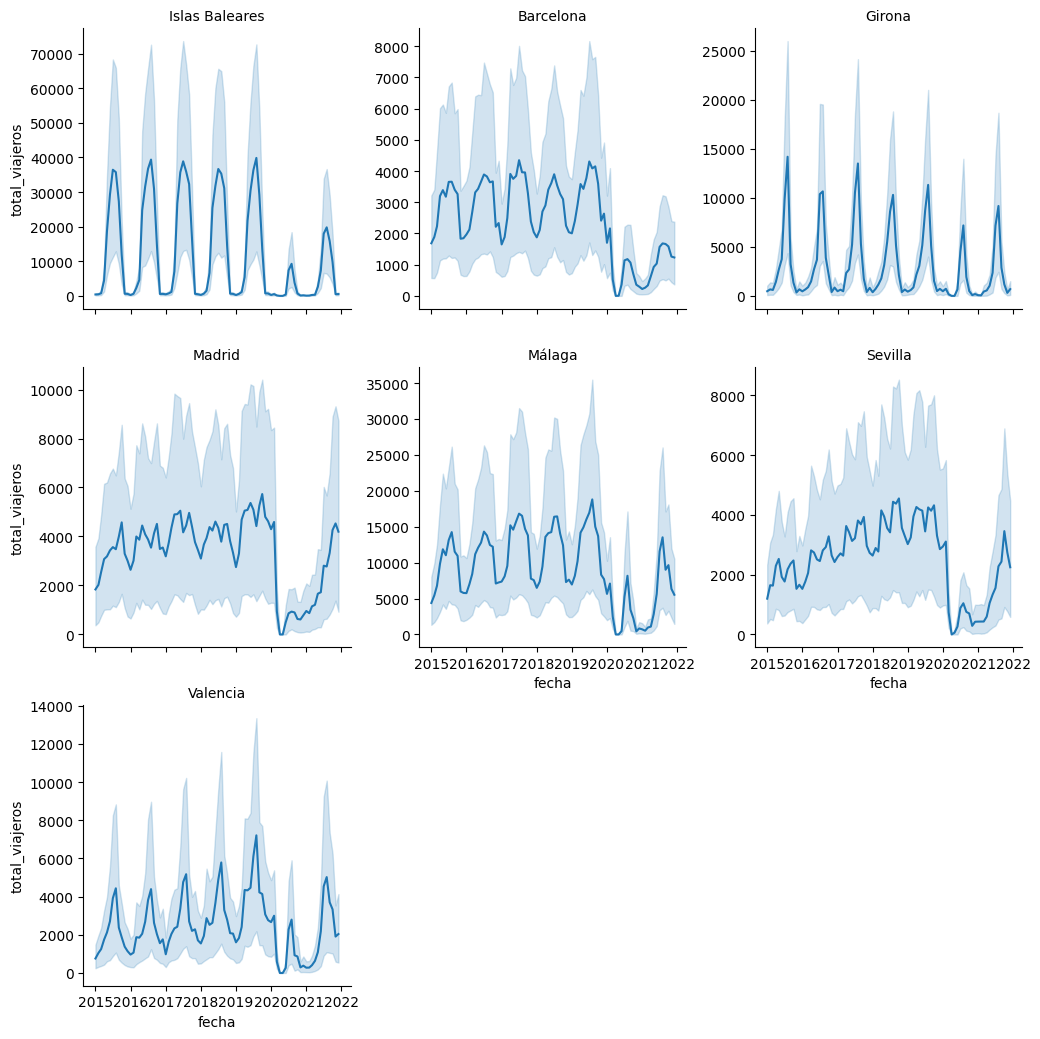

In [25]:
g = sns.FacetGrid(df, col='provincia', col_wrap=3, height=3.5, sharey=False)
g.map_dataframe(sns.lineplot, x='fecha', y='total_viajeros')
g.set_titles("{col_name}")
plt.show()


✔️ Un panel por provincia
✔️ Ideal para observar comportamiento individual
✔️ También para ver diferencias grandes entre destinos

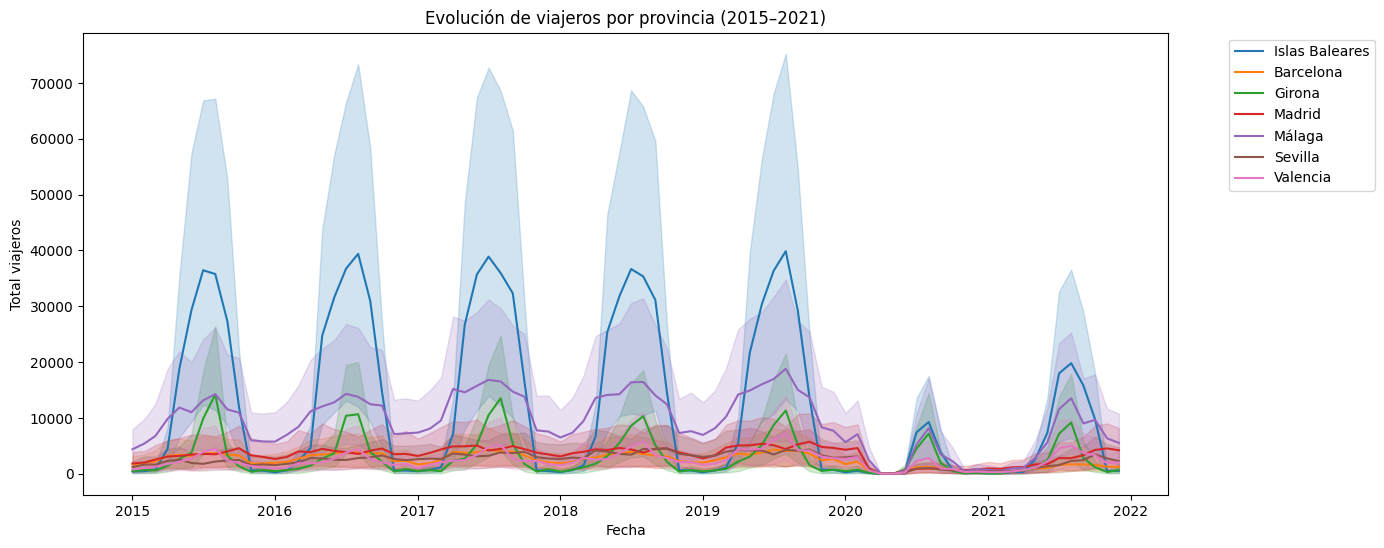

In [26]:
plt.figure(figsize=(14,6))
sns.lineplot(data=df, x='fecha', y='total_viajeros', hue='provincia')
plt.title('Evolución de viajeros por provincia (2015–2021)')
plt.xlabel('Fecha')
plt.ylabel('Total viajeros')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


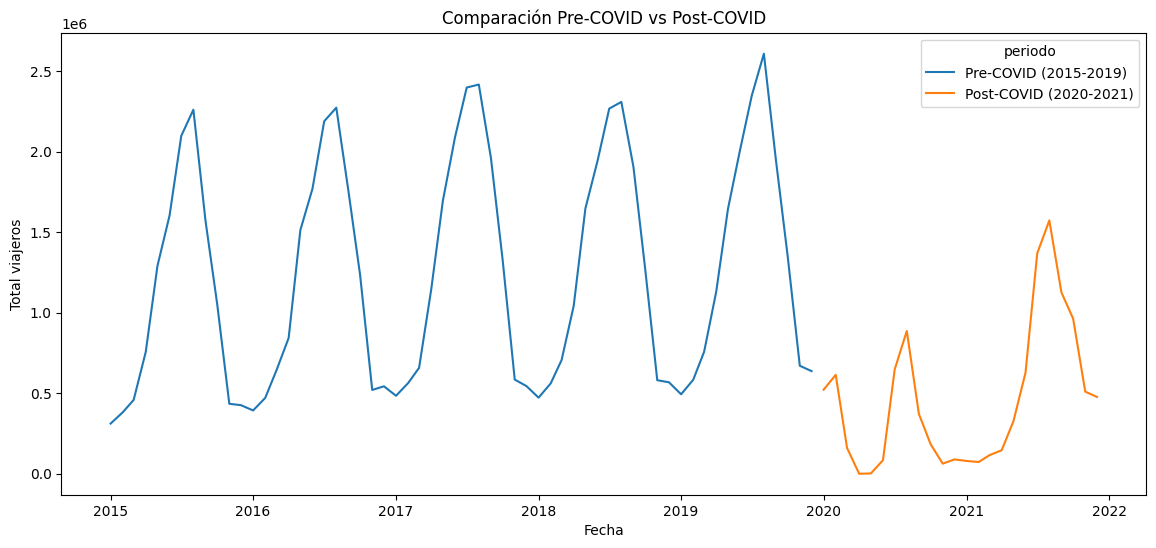

In [27]:
df['periodo'] = df['año'].apply(lambda x: 'Pre-COVID (2015-2019)' if x < 2020 else 'Post-COVID (2020-2021)')

df_periodos = df.groupby(['fecha','periodo'])['total_viajeros'].sum().reset_index()

plt.figure(figsize=(14,6))
sns.lineplot(data=df_periodos, x='fecha', y='total_viajeros', hue='periodo')
plt.title('Comparación Pre-COVID vs Post-COVID')
plt.xlabel('Fecha')
plt.ylabel('Total viajeros')
plt.show()


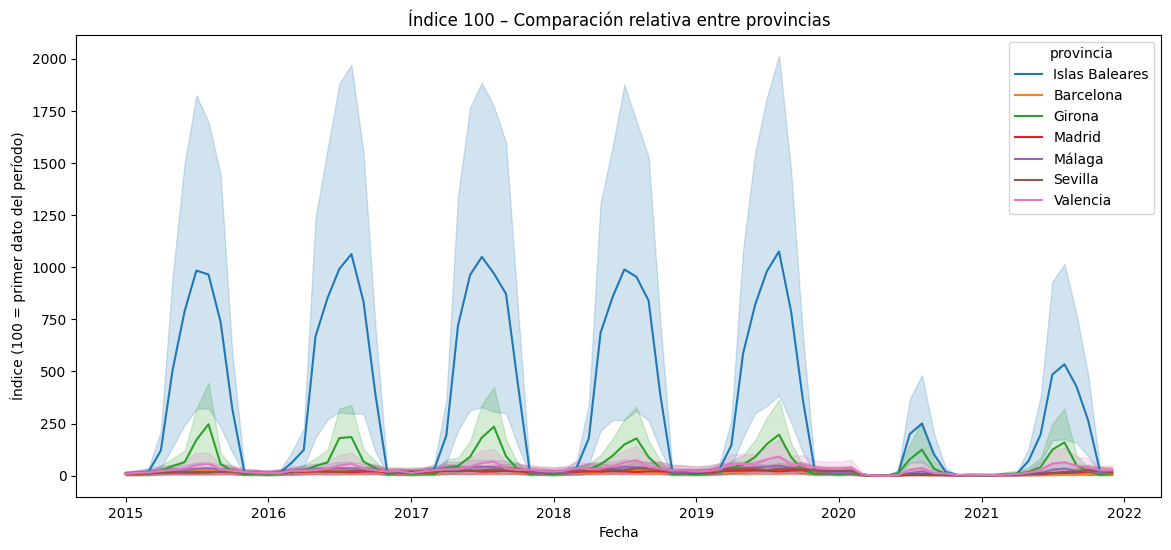

In [28]:
df_norm = df.copy()
df_norm['base'] = df_norm.groupby('provincia')['total_viajeros'].transform('first')
df_norm['indice'] = df_norm['total_viajeros'] / df_norm['base'] * 100

plt.figure(figsize=(14,6))
sns.lineplot(data=df_norm, x='fecha', y='indice', hue='provincia')
plt.title('Índice 100 – Comparación relativa entre provincias')
plt.xlabel('Fecha')
plt.ylabel('Índice (100 = primer dato del período)')
plt.show()
